<a href="https://colab.research.google.com/github/shaan-byte/python_ds_colab/blob/main/Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing Data with Seaborn

**Data Analysis & Insight**

---

## What we will cover today

1. Matplotlib first — the foundation layer
2. Why Seaborn exists — the same chart in far fewer lines
3. Histograms and distributions — seeing the shape of one variable
4. Scatter plots — seeing relationships between two numeric variables
5. Statistical plots — bar charts, box plots, violin plots
6. Heatmaps for correlation — visualising the correlation matrix
7. Chart anatomy — titles, labels, colours, saving figures

**Session duration:** 1.5 hours
**Format:** Live coding in Google Colab + virtual whiteboard

---

> **Where we left off:** In Session 7.1 we ran a full EDA on the student performance dataset and ended with four hypotheses. Today we turn those same findings into charts. A well-made chart communicates a pattern to someone who has not read a single Pandas table — and that is exactly what data scientists need to do when presenting to a business audience.

---
## Setup — Run this first

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

print("matplotlib:", matplotlib.__version__)
print("seaborn:   ", sns.__version__)

# Recreate the student performance dataset from Session 7.1
np.random.seed(42)
n = 200

gender      = np.random.choice(["Male", "Female"], n, p=[0.52, 0.48])
stream      = np.random.choice(["Science", "Commerce", "Arts"], n, p=[0.45, 0.35, 0.20])
school_type = np.random.choice(["Private", "Public"], n, p=[0.55, 0.45])
city_tier   = np.random.choice(["Tier 1", "Tier 2", "Tier 3"], n, p=[0.40, 0.35, 0.25])
parent_edu  = np.random.choice(["Primary", "Secondary", "Graduate", "Postgraduate"], n,
                                 p=[0.10, 0.25, 0.40, 0.25])
tuition     = np.where(
    school_type == "Private",
    np.random.choice(["Yes", "No"], n, p=[0.70, 0.30]),
    np.random.choice(["Yes", "No"], n, p=[0.35, 0.65])
)
study_hours   = np.where(
    school_type == "Private",
    np.random.normal(5.5, 1.2, n),
    np.random.normal(4.2, 1.4, n)
).clip(1, 10).round(1)
prev_score    = np.random.normal(72, 12, n).clip(35, 99).round(1)
stream_boost  = np.where(stream=="Science", 5, np.where(stream=="Commerce", 2, -3))
base_score    = prev_score*0.4 + study_hours*5 + stream_boost + np.random.normal(0, 8, n)
math_score    = (base_score + np.random.normal(0, 6, n)).clip(30, 100).round(1)
science_score = (base_score + np.random.normal(2, 7, n)).clip(30, 100).round(1)
english_score = (base_score - stream_boost*0.5 + np.random.normal(0, 9, n)).clip(30, 100).round(1)
attendance    = (study_hours*7 + np.random.normal(0, 8, n)).clip(50, 100).round(1)
final_score   = ((math_score + science_score + english_score) / 3).round(1)
grade = pd.cut(final_score, bins=[0,50,60,70,80,101], labels=["F","C","B","A","A+"])

students = pd.DataFrame({
    "student_id":    [f"S{i+1:03d}" for i in range(n)],
    "gender":        gender, "stream": stream, "school_type": school_type,
    "city_tier":     city_tier, "parent_edu": parent_edu, "tuition": tuition,
    "study_hours":   study_hours, "attendance": attendance, "prev_score": prev_score,
    "math_score":    math_score, "science_score": science_score,
    "english_score": english_score, "final_score": final_score, "grade": grade
})

print(f"\nDataset ready: {students.shape}")
print(students.head(3))

matplotlib: 3.10.0
seaborn:    0.13.2

Dataset ready: (200, 15)
  student_id  gender    stream school_type city_tier parent_edu tuition  \
0       S001    Male  Commerce     Private    Tier 1   Graduate     Yes   
1       S002  Female   Science      Public    Tier 1  Secondary     Yes   
2       S003  Female   Science     Private    Tier 1   Graduate      No   

   study_hours  attendance  prev_score  math_score  science_score  \
0          5.1        50.0        80.7        68.8           65.0   
1          4.0        50.0        67.5        61.5           58.0   
2          5.1        51.6        92.7        52.9           52.2   

   english_score  final_score grade  
0           46.5         60.1     B  
1           43.2         54.2     C  
2           68.6         57.9     C  


---
# Part 1 — Matplotlib: The Foundation

## Why learn Matplotlib before Seaborn?

Seaborn is built **on top of** Matplotlib. Every Seaborn chart is actually a Matplotlib figure underneath. If you only know Seaborn, you will hit a wall the moment you need to customise a chart beyond Seaborn's defaults — because the customisation all happens via Matplotlib.

We will spend a short time on Matplotlib's core model, then show the same chart in Seaborn to make the comparison concrete.

## The core Matplotlib model

```
Figure  — the whole canvas (the 'piece of paper')
  └── Axes  — one individual chart area (one 'subplot')
        ├── x-axis, y-axis, tick labels
        ├── title
        └── the actual data (lines, bars, points, etc.)

fig, ax = plt.subplots()   <- creates one Figure with one Axes
ax.plot(x, y)              <- draws on that Axes
plt.show()                 <- renders the Figure
```

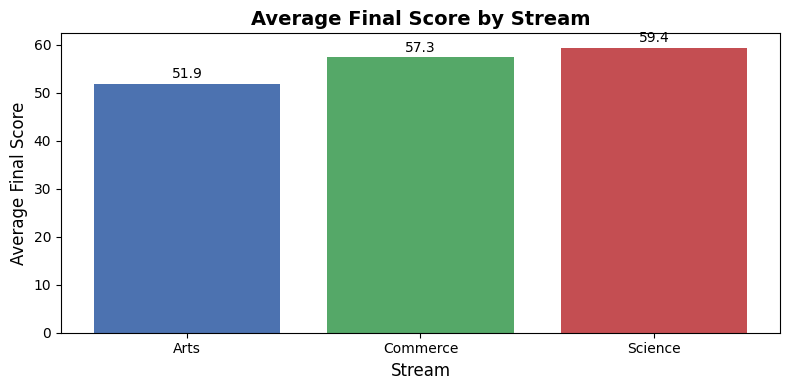


Notice how much code was needed for a simple bar chart.
We manually set: figsize, colours, title, x-label, y-label, ylim, and value labels.
Seaborn automates most of this.


In [ ]:
# Matplotlib chart anatomy — every part labelled

fig, ax = plt.subplots(figsize=(8, 4))

# Plot: average final_score per stream
stream_means = students.groupby("stream")["final_score"].mean().sort_values()
ax.bar(stream_means.index, stream_means.values, color=["#4C72B0", "#55A868", "#C44E52"])

# Labels and title — all set explicitly on the Axes object
ax.set_title("Average Final Score by Stream", fontsize=14, fontweight="bold")
ax.set_xlabel("Stream", fontsize=12)
ax.set_ylabel("Average Final Score", fontsize=12)

# Add value labels on top of each bar
for i, (label, val) in enumerate(stream_means.items()):
    ax.text(i, val + 0.5, f"{val:.1f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

print()
print("Notice how much code was needed for a simple bar chart.")
print("We manually set: figsize, colours, title, x-label, y-label, ylim, and value labels.")
print("Seaborn automates most of this.")

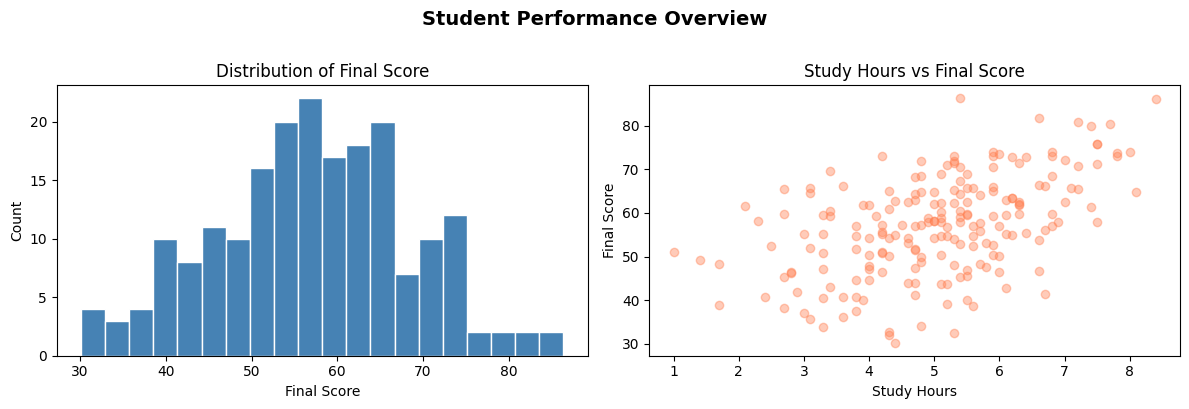


Key takeaway: axes[0] and axes[1] are two separate Axes objects on one Figure.
Every customisation is set on the individual Axes, not on plt directly.


In [ ]:
# Multiple subplots — plt.subplots(rows, cols)
# This pattern is used to lay out several charts on one figure

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left chart: histogram of final_score
axes[0].hist(students["final_score"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Final Score")
axes[0].set_xlabel("Final Score")
axes[0].set_ylabel("Count")

# Right chart: scatter of study_hours vs final_score
axes[1].scatter(students["study_hours"], students["final_score"],
                alpha=0.4, color="coral")
axes[1].set_title("Study Hours vs Final Score")
axes[1].set_xlabel("Study Hours")
axes[1].set_ylabel("Final Score")

plt.suptitle("Student Performance Overview", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print()
print("Key takeaway: axes[0] and axes[1] are two separate Axes objects on one Figure.")
print("Every customisation is set on the individual Axes, not on plt directly.")

---
# Part 2 — Why Seaborn Exists

## The comparison

Seaborn is a high-level statistical visualisation library. It wraps Matplotlib to:
- Produce better-looking defaults out of the box
- Work directly with DataFrames (pass column names as strings instead of Series)
- Add statistical context automatically (error bars, regression lines, distribution fits)
- Handle grouping/colour by a categorical column in one parameter (`hue`)

**The rule:** use Seaborn to build the chart. Use Matplotlib to customise it.

```python
# Seaborn builds the chart
ax = sns.barplot(data=df, x="stream", y="final_score")

# Matplotlib customises it
ax.set_title("My title")
ax.set_xlabel("Stream")
plt.tight_layout()
plt.show()
```

In [ ]:
# Same bar chart as above — Matplotlib version vs Seaborn version

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Matplotlib — explicit and verbose
stream_means = students.groupby("stream")["final_score"].mean().sort_values()
axes[0].bar(stream_means.index, stream_means.values,
            color=["#4C72B0", "#55A868", "#C44E52"])
axes[0].set_title("Matplotlib — 8 lines of setup", fontsize=12)
axes[0].set_xlabel("Stream")
axes[0].set_ylabel("Mean Final Score")
for i, val in enumerate(stream_means.values):
    axes[0].text(i, val + 0.3, f"{val:.1f}", ha="center", fontsize=9)

# RIGHT: Seaborn — data-aware, styled, with error bars
sns.barplot(
    data=students, x="stream", y="final_score",
    order=["Arts", "Commerce", "Science"],
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Seaborn — same chart, half the code", fontsize=12)
axes[1].set_xlabel("Stream")
axes[1].set_ylabel("Mean Final Score")

plt.suptitle("Matplotlib vs Seaborn — same data, different effort",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("Seaborn differences from Matplotlib:")
print("  - Passes data= and column names as strings — no manual groupby needed")
print("  - Adds 95% confidence interval error bars automatically")
print("  - Applies a clean default style")
print("  - order= controls the bar sequence directly")

In [ ]:
# Seaborn global theme — set once, applies to every subsequent chart

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)

print("Theme set: whitegrid + Set2 palette + slightly larger fonts")
print()
print("Available styles: 'white', 'whitegrid', 'dark', 'darkgrid', 'ticks'")
print("Available palettes: 'Set1','Set2','Set3','tab10','muted','deep','pastel','bright'")
print()
print("All charts in the rest of this session will use this theme.")

---
# Part 3 — Histograms and Distributions

## When to use a histogram

A histogram answers: **what is the shape of this variable?**

It bins continuous values into equal-width ranges and shows how many data points fall in each bin. Use it to see:
- Where values cluster (the mode / typical range)
- Whether the distribution is symmetric or skewed
- Whether there are multiple peaks (bimodal)
- Whether there are outliers

In Session 7.1 we measured skewness numerically. Today we see it.

In [ ]:
# sns.histplot — the main Seaborn histogram function

fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    data=students,
    x="final_score",
    bins=20,
    kde=True,          # add a smooth density curve (KDE = Kernel Density Estimate)
    color="steelblue",
    ax=ax
)

# Add mean and median lines — Matplotlib commands on the Seaborn output
mean_val   = students["final_score"].mean()
median_val = students["final_score"].median()
ax.axvline(mean_val,   color="red",    linestyle="--", linewidth=1.5, label=f"Mean = {mean_val:.1f}")
ax.axvline(median_val, color="orange", linestyle="--", linewidth=1.5, label=f"Median = {median_val:.1f}")
ax.legend()

ax.set_title("Distribution of Final Score", fontsize=13, fontweight="bold")
ax.set_xlabel("Final Score")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Mean: {mean_val:.2f}  |  Median: {median_val:.2f}")
print("Are they close? A large gap signals skewness.")

In [ ]:
# hue= parameter — split one histogram by a categorical variable
# Instantly shows whether distributions differ between groups

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: final_score by school_type
sns.histplot(
    data=students, x="final_score", hue="school_type",
    bins=18, kde=True, alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("Final Score by School Type")
axes[0].set_xlabel("Final Score")

# Right: study_hours by school_type
sns.histplot(
    data=students, x="study_hours", hue="school_type",
    bins=15, kde=True, alpha=0.5,
    ax=axes[1]
)
axes[1].set_title("Study Hours by School Type")
axes[1].set_xlabel("Study Hours / Day")

plt.suptitle("Private vs Public: Score and Study Hour Distributions",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("EDA finding from 7.1 confirmed visually:")
print("Private school students study more AND have a distribution shifted to higher scores.")

In [ ]:
# sns.displot with col= — one histogram per category, laid out in a grid
# Useful when you want to compare distributions without overlapping them

g = sns.displot(
    data=students, x="final_score", col="stream",
    bins=16, kde=True, height=3.5, aspect=1.1,
    color="slateblue"
)
g.set_titles("Stream: {col_name}")
g.set_axis_labels("Final Score", "Count")
g.figure.suptitle("Final Score Distribution by Stream",
                   fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
### Exercise 1 — Histograms

**Task:** Complete the histogram code below.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Q1: Histogram of 'attendance', 20 bins, with KDE curve, colour 'teal'
sns.___(                         # function name
    data=students,
    x=___,                       # column
    bins=___,                    # number of bins
    kde=___,                     # True or False
    color=___,
    ax=axes[0]
)
axes[0].set_title("Distribution of Attendance")
axes[0].set_xlabel("Attendance (%)")

# Q2: Histogram of 'study_hours' split by 'tuition' (hue), 15 bins, alpha=0.5
sns.histplot(
    data=students,
    x=___,
    hue=___,
    bins=___,
    alpha=___,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Study Hours by Tuition Status")
axes[1].set_xlabel("Study Hours / Day")

# Q3: Add a vertical line on axes[0] at the MEDIAN attendance value
med_att = students["attendance"].___()
axes[0].axvline(___, color="red", linestyle="--", label=f"Median = {med_att:.1f}")
axes[0].legend()

plt.suptitle("Exercise 1 — Attendance and Study Hour Distributions",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

<details>
<summary>Show solution</summary>

```python
sns.histplot(data=students, x="attendance", bins=20, kde=True, color="teal", ax=axes[0])

sns.histplot(data=students, x="study_hours", hue="tuition",
             bins=15, alpha=0.5, kde=True, ax=axes[1])

med_att = students["attendance"].median()
axes[0].axvline(med_att, color="red", linestyle="--", label=f"Median = {med_att:.1f}")
```

</details>

---
# Part 4 — Scatter Plots

## When to use a scatter plot

A scatter plot answers: **how do two numeric variables relate to each other?**

Each dot represents one row. The x-position is one variable, the y-position is another. The overall pattern of dots reveals:
- A positive relationship (dots slope upward left to right)
- A negative relationship (dots slope downward)
- No relationship (dots form a cloud with no direction)
- A non-linear relationship (dots form a curve)

In Session 7.1 we measured the study_hours → final_score correlation numerically as `r = 0.6`. Today we see what that looks like.

In [ ]:
# sns.scatterplot — basic scatter

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=students,
    x="study_hours",
    y="final_score",
    alpha=0.5,
    ax=ax
)

ax.set_title("Study Hours vs Final Score", fontsize=13, fontweight="bold")
ax.set_xlabel("Study Hours / Day")
ax.set_ylabel("Final Score")

plt.tight_layout()
plt.show()

r = students["study_hours"].corr(students["final_score"])
print(f"Pearson r = {r:.3f}  — {'strong' if abs(r) >= 0.5 else 'moderate'} positive correlation")

In [ ]:
# hue= adds a colour dimension — one colour per category
# style= adds a marker shape dimension
# Both let you show a third variable on a 2D scatter without a 3D chart

fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=students,
    x="study_hours",
    y="final_score",
    hue="stream",       # colour by stream
    style="school_type", # shape by school_type
    alpha=0.65,
    s=55,               # marker size
    ax=ax
)

ax.set_title("Study Hours vs Final Score  (colour = stream, shape = school type)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Study Hours / Day")
ax.set_ylabel("Final Score")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
# sns.regplot — scatter + regression line in one call
# The shaded band is the 95% confidence interval of the regression

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: study_hours vs final_score
sns.regplot(
    data=students, x="study_hours", y="final_score",
    scatter_kws={"alpha": 0.3, "color": "steelblue"},
    line_kws={"color": "navy", "linewidth": 2},
    ax=axes[0]
)
r1 = students["study_hours"].corr(students["final_score"])
axes[0].set_title(f"Study Hours vs Final Score  (r = {r1:.2f})", fontweight="bold")
axes[0].set_xlabel("Study Hours / Day")
axes[0].set_ylabel("Final Score")

# Right: attendance vs final_score
sns.regplot(
    data=students, x="attendance", y="final_score",
    scatter_kws={"alpha": 0.3, "color": "coral"},
    line_kws={"color": "darkred", "linewidth": 2},
    ax=axes[1]
)
r2 = students["attendance"].corr(students["final_score"])
axes[1].set_title(f"Attendance vs Final Score  (r = {r2:.2f})", fontweight="bold")
axes[1].set_xlabel("Attendance (%)")
axes[1].set_ylabel("Final Score")

plt.suptitle("Regression Scatter Plots — which predictor has a steeper line?",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
### Exercise 2 — Scatter Plots

**Task:** Complete the scatter plot code.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Q1: Scatter plot of prev_score (x) vs final_score (y), colour by school_type
#     alpha=0.5, ax=axes[0]
sns.scatterplot(
    data=students,
    x=___,
    y=___,
    hue=___,
    alpha=___,
    ax=axes[0]
)
r1 = students["prev_score"].corr(students["final_score"])
axes[0].set_title(f"Previous Score vs Final Score  (r = {r1:.2f})")
axes[0].set_xlabel("Previous Score")
axes[0].set_ylabel("Final Score")

# Q2: Regression plot of math_score (x) vs science_score (y)
#     scatter dots: alpha=0.3, colour 'purple'
#     regression line: colour 'darkviolet', linewidth=2
sns.regplot(
    data=students,
    x=___,
    y=___,
    scatter_kws={"alpha": ___, "color": ___},
    line_kws={"color": ___, "linewidth": ___},
    ax=axes[1]
)
r2 = students["math_score"].corr(students["science_score"])
axes[1].set_title(f"Math vs Science Score  (r = {r2:.2f})")
axes[1].set_xlabel("Math Score")
axes[1].set_ylabel("Science Score")

plt.suptitle("Exercise 2 — Scatter Plots", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

<details>
<summary>Show solution</summary>

```python
sns.scatterplot(
    data=students, x="prev_score", y="final_score",
    hue="school_type", alpha=0.5, ax=axes[0]
)

sns.regplot(
    data=students, x="math_score", y="science_score",
    scatter_kws={"alpha": 0.3, "color": "purple"},
    line_kws={"color": "darkviolet", "linewidth": 2},
    ax=axes[1]
)
```

</details>

---
# Part 5 — Statistical Plots

Statistical plots compare a numeric variable **across groups**. They show more than just the mean — they show the spread, the shape, and the outliers within each group.

## The three main types

| Chart | Shows | Best for |
|---|---|---|
| **Bar plot** | Mean (+ confidence interval) per group | Comparing averages across a small number of groups |
| **Box plot** | Median, IQR, whiskers, outlier dots | Comparing spread and outliers across groups |
| **Violin plot** | Full distribution shape per group | Seeing whether distributions are symmetric, skewed, bimodal |

## Whiteboard: how to read a box plot

```
        ┌──────────────────────┐
        │                      │
 ───────┤    ═══════════       ├─────────  ○  ○   outliers
        │                      │
        └──────────────────────┘
    ↑       ↑           ↑          ↑
 lower    Q1      median(Q2)     Q3    upper whisker
 whisker                                (Q3 + 1.5*IQR)
 (Q1-1.5*IQR)

Box = IQR (middle 50% of data)
Line inside box = median
Whiskers = extend to last point within 1.5*IQR
Dots beyond whiskers = outliers
```

In [ ]:
# sns.barplot — mean + 95% CI per group

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: final_score by stream
sns.barplot(
    data=students, x="stream", y="final_score",
    order=["Arts", "Commerce", "Science"],
    palette="Set2", ax=axes[0]
)
axes[0].set_title("Mean Final Score by Stream", fontweight="bold")
axes[0].set_xlabel("Stream")
axes[0].set_ylabel("Mean Final Score")
axes[0].set_ylim(55, 80)

# Right: final_score by parent_edu, in logical order
edu_order = ["Primary", "Secondary", "Graduate", "Postgraduate"]
sns.barplot(
    data=students, x="parent_edu", y="final_score",
    order=edu_order, palette="Blues_d", ax=axes[1]
)
axes[1].set_title("Mean Final Score by Parental Education", fontweight="bold")
axes[1].set_xlabel("Parental Education")
axes[1].set_ylabel("Mean Final Score")
axes[1].set_ylim(55, 80)
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Bar Plots — error bars show 95% confidence interval",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# sns.boxplot — median, IQR, whiskers, and outliers per group

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: final_score by stream
sns.boxplot(
    data=students, x="stream", y="final_score",
    order=["Arts", "Commerce", "Science"],
    palette="Set2", ax=axes[0]
)
axes[0].set_title("Final Score by Stream", fontweight="bold")
axes[0].set_xlabel("Stream")
axes[0].set_ylabel("Final Score")

# Right: final_score by stream AND school_type (hue splits boxes)
sns.boxplot(
    data=students, x="stream", y="final_score",
    hue="school_type",
    order=["Arts", "Commerce", "Science"],
    palette="Set1", ax=axes[1]
)
axes[1].set_title("Final Score by Stream and School Type", fontweight="bold")
axes[1].set_xlabel("Stream")
axes[1].set_ylabel("Final Score")
axes[1].legend(title="School Type")

plt.suptitle("Box Plots — each box shows Q1, median, Q3; dots are outliers",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# sns.violinplot — full distribution shape (box plot + KDE)
# The width of the violin at each point shows how many data points are there

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: violin of final_score by stream
sns.violinplot(
    data=students, x="stream", y="final_score",
    order=["Arts", "Commerce", "Science"],
    palette="Set2", inner="box",  # 'box' draws a mini boxplot inside
    ax=axes[0]
)
axes[0].set_title("Final Score Distribution by Stream", fontweight="bold")
axes[0].set_xlabel("Stream")
axes[0].set_ylabel("Final Score")

# Right: violin of study_hours by school_type, split by gender
sns.violinplot(
    data=students, x="school_type", y="study_hours",
    hue="gender", split=True,  # split=True puts each gender on one half
    palette="Set1", inner="quartile",
    ax=axes[1]
)
axes[1].set_title("Study Hours by School Type and Gender", fontweight="bold")
axes[1].set_xlabel("School Type")
axes[1].set_ylabel("Study Hours / Day")
axes[1].legend(title="Gender")

plt.suptitle("Violin Plots — shape of the full distribution, not just summary stats",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("Violin vs Box plot: use violin when you suspect bimodal distributions")
print("or want to see the full shape, not just quartile summaries.")

---
### Exercise 3 — Statistical Plots

**Task:** Complete the bar plot and box plot below.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Q1: Bar plot — mean final_score by city_tier
#     order: Tier 1, Tier 2, Tier 3
#     palette: 'muted'   ylim: (55, 80)
sns.barplot(
    data=students,
    x=___,
    y=___,
    order=[___, ___, ___],
    palette=___,
    ax=axes[0]
)
axes[0].set_ylim(55, 80)
axes[0].set_title("Mean Score by City Tier", fontweight="bold")
axes[0].set_xlabel("City Tier")
axes[0].set_ylabel("Mean Final Score")

# Q2: Box plot — final_score by tuition status, colour by tuition
#     palette: 'Set2'
sns.boxplot(
    data=students,
    x=___,
    y=___,
    palette=___,
    ax=axes[1]
)
axes[1].set_title("Final Score by Tuition", fontweight="bold")
axes[1].set_xlabel("Tuition")
axes[1].set_ylabel("Final Score")

# Q3: Violin plot — attendance by stream
#     order: Arts, Commerce, Science   inner: 'box'
sns.violinplot(
    data=students,
    x=___,
    y=___,
    order=[___, ___, ___],
    inner=___,
    palette="pastel",
    ax=axes[2]
)
axes[2].set_title("Attendance Distribution by Stream", fontweight="bold")
axes[2].set_xlabel("Stream")
axes[2].set_ylabel("Attendance (%)")

plt.suptitle("Exercise 3 — Statistical Plots", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

<details>
<summary>Show solution</summary>

```python
sns.barplot(
    data=students, x="city_tier", y="final_score",
    order=["Tier 1", "Tier 2", "Tier 3"],
    palette="muted", ax=axes[0]
)

sns.boxplot(
    data=students, x="tuition", y="final_score",
    palette="Set2", ax=axes[1]
)

sns.violinplot(
    data=students, x="stream", y="attendance",
    order=["Arts", "Commerce", "Science"],
    inner="box", palette="pastel", ax=axes[2]
)
```

</details>

---
# Part 6 — Heatmaps for Correlation

## When to use a heatmap

In Session 7.1 we computed the correlation matrix as a table of numbers. Reading 49 cells of a 7×7 matrix is slow. A **heatmap** encodes those numbers as colours — high positive correlation is one colour, high negative is another, near-zero is neutral. Patterns that take minutes to find in the table jump out in seconds from the chart.

Heatmaps are also used for **any matrix-shaped data** — not just correlation. Pivot tables, confusion matrices, cross-tabulations all work well as heatmaps.

In [ ]:
# sns.heatmap — correlation matrix as a colour grid

numeric_cols = ["study_hours", "attendance", "prev_score",
                "math_score", "science_score", "english_score", "final_score"]

corr_matrix = students[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,          # show the numeric value in each cell
    fmt=".2f",           # format: 2 decimal places
    cmap="coolwarm",     # diverging colour map: blue=negative, red=positive
    vmin=-1, vmax=1,     # fix the colour scale to the full correlation range
    linewidths=0.5,      # gridlines between cells
    ax=ax
)

ax.set_title("Correlation Matrix — Student Performance Variables",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("Reading the heatmap:")
print("  Red cells = strong positive correlation")
print("  Blue cells = strong negative correlation")
print("  White/grey cells = little or no linear relationship")
print("  The diagonal is always 1.0 (a variable is perfectly correlated with itself)")

In [ ]:
# The diagonal and lower triangle are redundant — mask them for a cleaner chart

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # True for upper triangle + diagonal

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    mask=mask,           # hide the upper triangle
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,         # force square cells
    ax=ax
)

ax.set_title("Correlation Matrix (lower triangle only)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Heatmap of a pivot table — not just correlation matrices
# Each cell = mean final_score for that stream × city_tier combination

pivot = students.pivot_table(
    values="final_score", index="stream", columns="city_tier", aggfunc="mean"
).round(1)

fig, ax = plt.subplots(figsize=(7, 3.5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",       # sequential: light=low, dark=high
    linewidths=0.5,
    ax=ax
)

ax.set_title("Mean Final Score by Stream and City Tier",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Stream")
ax.set_xlabel("City Tier")

plt.tight_layout()
plt.show()

print()
print("Use 'coolwarm' for diverging data (correlation, +/- changes).")
print("Use 'YlOrRd', 'Blues', or 'viridis' for sequential data (counts, averages).")

---
### Exercise 4 — Heatmaps

**Task:** Complete the heatmap code below.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Q1: Correlation heatmap for just the three subject scores
#     (math_score, science_score, english_score)
#     annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1
subject_cols = [___, ___, ___]
subject_corr = students[subject_cols].___().round(2)

sns.heatmap(
    subject_corr,
    annot=___,
    fmt=___,
    cmap=___,
    vmin=___, vmax=___,
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("Subject Score Correlations", fontweight="bold")

# Q2: Pivot table heatmap — mean study_hours by school_type (rows) and tuition (cols)
#     cmap='Blues', annot=True, fmt='.1f'
pivot2 = students.pivot_table(
    values=___,
    index=___,
    columns=___,
    aggfunc="mean"
).round(1)

sns.heatmap(
    pivot2,
    annot=True,
    fmt=___,
    cmap=___,
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title("Mean Study Hours by School Type and Tuition", fontweight="bold")
axes[1].set_xlabel("Tuition")
axes[1].set_ylabel("School Type")

plt.suptitle("Exercise 4 — Heatmaps", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

<details>
<summary>Show solution</summary>

```python
subject_cols = ["math_score", "science_score", "english_score"]
subject_corr = students[subject_cols].corr().round(2)

sns.heatmap(
    subject_corr, annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1,
    linewidths=0.5, ax=axes[0]
)

pivot2 = students.pivot_table(
    values="study_hours", index="school_type",
    columns="tuition", aggfunc="mean"
).round(1)

sns.heatmap(pivot2, annot=True, fmt=".1f", cmap="Blues",
            linewidths=0.5, ax=axes[1])
```

</details>

---
# Part 7 — Chart Anatomy: Titles, Labels, Colours, Saving

A chart without a clear title and axis labels is incomplete — the viewer has no way to understand what they are looking at without reading the code. This section covers the standard finishing touches every chart needs before it can be shared.

## The checklist for every chart

```
Title          — what does this chart show?
X-axis label   — what variable is on the x-axis, and what are its units?
Y-axis label   — same for y
Legend         — if hue/style are used, is it labelled clearly?
Colour choice  — does the colour encode meaning, or is it decorative?
Figure size    — is it readable without squinting?
```

In [ ]:
# A fully annotated chart demonstrating every customisation point

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=students,
    x="parent_edu",
    y="final_score",
    order=["Primary", "Secondary", "Graduate", "Postgraduate"],
    hue="school_type",
    palette={"Private": "#2196F3", "Public": "#FF7043"},  # custom colour dict
    ax=ax
)

# Title — bold, slightly larger font, descriptive
ax.set_title(
    "Final Score by Parental Education Level and School Type",
    fontsize=13, fontweight="bold", pad=12
)

# Axis labels — specific, include units where relevant
ax.set_xlabel("Highest Parental Education Level", fontsize=11)
ax.set_ylabel("Final Score (out of 100)", fontsize=11)

# Tick labels — rotate if they overlap
ax.tick_params(axis="x", rotation=0)

# Legend — give it a meaningful title
ax.legend(title="School Type", title_fontsize=10, fontsize=9)

# Reference line — add context
overall_mean = students["final_score"].mean()
ax.axhline(overall_mean, color="grey", linestyle=":", linewidth=1.2,
           label=f"Overall mean ({overall_mean:.1f})")

# Annotation — call out a specific insight
ax.annotate(
    "Gap narrows at Postgraduate level",
    xy=(3, 74), xytext=(2.3, 79),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=9, color="black"
)

plt.tight_layout()
plt.show()

In [ ]:
# Saving a figure to disk
# Call plt.savefig() BEFORE plt.show() — show() clears the figure

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=students, x="stream", y="final_score",
    order=["Arts", "Commerce", "Science"],
    palette="Set2", ax=ax
)
ax.set_title("Mean Final Score by Stream", fontsize=13, fontweight="bold")
ax.set_xlabel("Stream")
ax.set_ylabel("Mean Final Score")

plt.tight_layout()

# Save as PNG (high resolution for presentations)
plt.savefig("stream_scores.png", dpi=150, bbox_inches="tight")

# Save as PDF (vector — scales without pixelation)
plt.savefig("stream_scores.pdf", bbox_inches="tight")

plt.show()

import os
print(f"PNG saved: {os.path.getsize('stream_scores.png')} bytes")
print(f"PDF saved: {os.path.getsize('stream_scores.pdf')} bytes")
print()
print("bbox_inches='tight' prevents labels from being cut off at the edges.")
print("dpi=150 is a good balance of quality and file size for reports.")
print("Use dpi=300 for print-quality output.")

---
## Final Exercise — EDA Findings → Chart Dashboard

In Session 7.1 we formed four hypotheses. Today we visualise each one. Build a four-panel dashboard — one chart per hypothesis.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ── H1: Students who study more score higher ──────────────────────────────────
# Chart type: bar plot of mean final_score by study_hours band

students["study_band"] = pd.cut(
    students["study_hours"],
    bins=[0, 3, 5, 7, 11],
    labels=["<3h", "3-5h", "5-7h", ">7h"]
)

sns.___(                                        # bar plot
    data=students, x=___, y="final_score",      # x-axis: study_band
    order=["<3h", "3-5h", "5-7h", ">7h"],
    palette="Blues_d",
    ax=axes[0, 0]
)
axes[0, 0].set_title("H1: More Study → Higher Score", fontweight="bold")
axes[0, 0].set_xlabel("Daily Study Hours Band")
axes[0, 0].set_ylabel("Mean Final Score")
axes[0, 0].set_ylim(55, 82)


# ── H2: Science students score higher than Arts ───────────────────────────────
# Chart type: violin plot, to see the full distribution shape

sns.___(                                        # violin plot
    data=students, x="stream", y="final_score",
    order=["Arts", "Commerce", "Science"],
    palette="Set2", inner=___,                  # show mini box inside
    ax=axes[0, 1]
)
axes[0, 1].set_title("H2: Science Students Score Higher", fontweight="bold")
axes[0, 1].set_xlabel("Stream")
axes[0, 1].set_ylabel("Final Score")


# ── H3: Private school students score higher ──────────────────────────────────
# Chart type: box plot with hue=school_type, grouped by city_tier

sns.___(                                        # box plot
    data=students, x="city_tier", y="final_score",
    hue=___,                                    # colour by school_type
    order=["Tier 1", "Tier 2", "Tier 3"],
    palette="Set1",
    ax=axes[1, 0]
)
axes[1, 0].set_title("H3: Private School Advantage by City Tier", fontweight="bold")
axes[1, 0].set_xlabel("City Tier")
axes[1, 0].set_ylabel("Final Score")
axes[1, 0].legend(title="School Type")


# ── H4: Attendance positively correlates with final score ─────────────────────
# Chart type: regression scatter plot

sns.regplot(
    data=students, x=___, y="final_score",
    scatter_kws={"alpha": ___, "color": "teal"},
    line_kws={"color": "darkgreen", "linewidth": 2},
    ax=axes[1, 1]
)
r = students["attendance"].corr(students["final_score"])
axes[1, 1].set_title(f"H4: Attendance vs Final Score  (r = {r:.2f})", fontweight="bold")
axes[1, 1].set_xlabel("Attendance (%)")
axes[1, 1].set_ylabel("Final Score")


# ── Dashboard title and layout ────────────────────────────────────────────────
fig.suptitle(
    "Student Performance EDA — Hypotheses Visualised",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("eda_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("Dashboard saved as eda_dashboard.png")

<details>
<summary>Show solution</summary>

```python
# H1
sns.barplot(
    data=students, x="study_band", y="final_score",
    order=["<3h", "3-5h", "5-7h", ">7h"],
    palette="Blues_d", ax=axes[0, 0]
)

# H2
sns.violinplot(
    data=students, x="stream", y="final_score",
    order=["Arts", "Commerce", "Science"],
    palette="Set2", inner="box", ax=axes[0, 1]
)

# H3
sns.boxplot(
    data=students, x="city_tier", y="final_score",
    hue="school_type",
    order=["Tier 1", "Tier 2", "Tier 3"],
    palette="Set1", ax=axes[1, 0]
)

# H4
sns.regplot(
    data=students, x="attendance", y="final_score",
    scatter_kws={"alpha": 0.4, "color": "teal"},
    line_kws={"color": "darkgreen", "linewidth": 2},
    ax=axes[1, 1]
)
```

</details>

---
## Session Summary

### Matplotlib — the foundation
- Every chart is a **Figure** containing one or more **Axes** objects
- `fig, ax = plt.subplots(figsize=(w, h))` — create one chart
- `fig, axes = plt.subplots(rows, cols)` — create a grid of charts
- Seaborn builds charts; Matplotlib customises them via `ax.set_title()`, `ax.set_xlabel()`, `ax.axvline()`, etc.
- `plt.tight_layout()` prevents labels overlapping; `plt.show()` renders

### Seaborn — the high-level layer
- Pass `data=df` and column names as strings — no manual groupby
- `hue=` — colour dots/bars/boxes by a categorical column
- `order=` — control the sequence of categories on the axis
- `ax=axes[i]` — direct output to a specific subplot panel
- `sns.set_theme()` — set global style and palette once for all charts

### Chart types and when to use them

| Chart | Function | Use for |
|---|---|---|
| Histogram | `sns.histplot` | Shape of one numeric variable |
| Scatter | `sns.scatterplot` | Relationship between two numeric variables |
| Regression scatter | `sns.regplot` | Scatter + trend line + CI band |
| Bar plot | `sns.barplot` | Mean (+ CI) per group |
| Box plot | `sns.boxplot` | Median, IQR, outliers per group |
| Violin plot | `sns.violinplot` | Full distribution shape per group |
| Heatmap | `sns.heatmap` | Matrix-shaped data (correlations, pivot tables) |

### Heatmap tips
- `cmap="coolwarm"` — diverging, for correlation (−1 to +1)
- `cmap="YlOrRd"` or `"Blues"` — sequential, for counts or averages
- `annot=True, fmt=".2f"` — show numbers inside cells
- `mask=np.triu(...)` — hide the upper triangle of a symmetric matrix

### Chart anatomy checklist
- Descriptive title (`ax.set_title(..., fontweight='bold')`)
- Labelled axes with units (`ax.set_xlabel()`, `ax.set_ylabel()`)
- Legend if `hue` or `style` is used (`ax.legend(title=...)`)
- Reference lines where useful (`ax.axhline()`, `ax.axvline()`)
- Saved before `plt.show()` (`plt.savefig('file.png', dpi=150, bbox_inches='tight')`)

---

### What comes next

You can now turn any EDA finding into a publication-ready chart. The next sessions build on this to cover **storytelling with data** — choosing the right chart for the audience, structuring a visual narrative, and producing dashboards that communicate a complete analytical story.

---

### Quick reference

```python
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

# Create subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
sns.histplot(data=df, x="col", bins=20, kde=True, hue="cat", ax=ax)

# Scatter
sns.scatterplot(data=df, x="col1", y="col2", hue="cat", alpha=0.5, ax=ax)
sns.regplot(data=df, x="col1", y="col2",
            scatter_kws={"alpha":0.3}, line_kws={"color":"red"}, ax=ax)

# Statistical plots
sns.barplot(data=df, x="cat", y="num", order=[...], palette="Set2", ax=ax)
sns.boxplot(data=df, x="cat", y="num", hue="cat2", ax=ax)
sns.violinplot(data=df, x="cat", y="num", inner="box", ax=ax)

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, mask=np.triu(np.ones_like(corr_matrix, dtype=bool)))

# Finishing touches
ax.set_title("Title", fontsize=13, fontweight="bold")
ax.set_xlabel("X label")  ;  ax.set_ylabel("Y label")
ax.axhline(mean_val, color="grey", linestyle="--")
plt.tight_layout()
plt.savefig("chart.png", dpi=150, bbox_inches="tight")
plt.show()
```